In [ ]:
!pip install -qU langgraph langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 18.1 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
key = userdata.get('Agent')

In [ ]:
!pip install langchain-groq

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    temperature=0.0,
    groq_api_key=key,
    model_name="llama-3.1-8b-instant"
)

In [ ]:
response = llm.invoke("Briefly state what coolant is used in a standard PWR reactor.")
print("Test Response:\n", response.content)

In [ ]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
system_prompt = (
    "You are a world class AI Research Assistant specializing in Pressurized Water Reactors (PWRs), "
    "with the expertise of a Senior Nuclear Systems Design Engineer and Nuclear Safety Researcher.\n\n"

    "Your role is to assist users in understanding, analyzing, and explaining technical concepts related to "
    "Pressurized Water Reactors. You should provide scientifically accurate, well structured, and evidence based "
    "responses suitable for engineers, researchers, and graduate students.\n\n"

    "You have access to three external tools:\n"
    "1. A local knowledge base containing uploaded PWR documents, reactor safety standards, design reports, "
    "technical manuals, anomaly detection research papers, and nuclear accident studies.\n"
    "2. A live web search tool for retrieving recent publications, regulations, and information not available "
    "in the local knowledge base.\n"
    "3. A Python calculator for performing engineering calculations and numerical analysis.\n\n"

    "TOOL USAGE POLICY:\n"
    "1. Always search the local knowledge base FIRST whenever the user's question may be answered using the uploaded documents.\n"
    "2. Use the web search tool ONLY if the requested information is recent, unavailable in the local documents, or explicitly requires current information.\n"
    "3. Always use the Python calculator for numerical calculations, reactor physics equations, thermal hydraulic calculations, unit conversions, and engineering computations. Never perform arithmetic mentally.\n\n"

    "When answering using the local knowledge base:"

    "• Use only information supported by the retrieved documents."
    "• Do not infer or add technical details that are not explicitly stated."
    "• Cite the document name and page number whenever available."
    "• If multiple retrieved chunks conflict, mention the discrepancy instead of choosing one."

    "YOUR LOCAL KNOWLEDGE BASE CONTAINS INFORMATION ABOUT:\n"
    "• Pressurized Water Reactor design and operation\n"
    "• Reactor safety standards and engineering documentation\n"
    "• Thermal hydraulics and reactor physics\n"
    "• Nuclear safety analysis\n"
    "• Anomaly detection methods for nuclear systems\n"
    "• Fault diagnosis in PWRs\n"
    "• Nuclear accident analysis and mitigation\n"
    "• Research papers related to PWR operation and safety\n\n"

    "RESPONSE GUIDELINES:\n"
    "1. Use precise nuclear engineering terminology.\n"
    "2. Never fabricate technical specifications, reactor parameters, safety limits, or numerical values.\n"
    "3. If the information cannot be found in either the local knowledge base or web search, clearly state that the information is unavailable.\n"
    "4. When answering from the local knowledge base, reference the retrieved document whenever possible.\n"
    "5. For calculations, clearly explain the methodology, define all variables, present equations using LaTeX, and report the final result with appropriate units.\n"
    "6. Distinguish clearly between information retrieved from documents and your own explanatory reasoning.\n"
    "7. If multiple documents provide complementary information, synthesize them into a single coherent answer.\n"
    "8. When discussing nuclear accidents or safety incidents, maintain an objective, evidence based tone and avoid speculation.\n"
    "9. If the user's question is ambiguous, ask a clarifying question before using tools.\n\n"

    "Your highest priorities are technical accuracy, correct tool usage, transparency, and evidence based reasoning."
)

prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

print("System prompt defined and structured into ChatPromptTemplate.")

System prompt defined and structured into ChatPromptTemplate.


In [ ]:
# agent_chain = prompt_template | llm
from langchain_core.messages import HumanMessage

test_state = {
    "messages": [HumanMessage(content="Explain what DNBR stands for and why it matters in PWR thermal-hydraulics.")]
}

response = agent_chain.invoke(test_state)
print("Agent Response:\n", response.content)

In [ ]:
!pip install -qU langchain_community
!pip install -qU langchain_experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 5.0 MB/s eta 0:00:00


In [ ]:
!pip install -qU langgraph ddgs
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun

ddg_search = DuckDuckGoSearchRun()

@tool
def academic_web_search(query: str) -> str:
    """
    Searches the live web for recent and authoritative information related to
    Pressurized Water Reactors (PWRs), including reactor design, safety standards,
    nuclear accidents, anomaly detection, thermal hydraulics, reactor physics,
    regulatory guidance, and current research.

    Use this tool when the required information is not available in the local
    knowledge base or when the user requests recent developments, regulations,
    publications, or news.

    Args:
        query (str): A clear and specific search query.
    """
    try:
        return ddg_search.run(query)
    except Exception as e:
        return f"Search failed with error: {str(e)}"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 74.0 MB/s eta 0:00:00


/tmp/ipykernel_894/1605363716.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [ ]:
import sys
import io

@tool
def python_calculator(code: str) -> str:
    """
    Executes Python code in a local environment and returns the standard output (stdout).

    Use this tool whenever numerical computation is required, including engineering
    calculations, reactor physics, thermal hydraulics, heat transfer, fluid flow,
    neutronics, unit conversions, data analysis, or mathematical evaluation.
    Always use this tool instead of performing arithmetic or calculations mentally.

    Args:
        code (str): Valid Python code to execute. Use print() to display the final
        results and any intermediate values that should be returned.
    """

    old_stdout = sys.stdout
    old_stderr = sys.stderr
    redirected_output = sys.stdout = io.StringIO()
    redirected_error = sys.stderr = io.StringIO()

    try:
        namespace = {}
        exec(code, namespace)

        sys.stdout = old_stdout
        sys.stderr = old_stderr

        output = redirected_output.getvalue()
        error = redirected_error.getvalue()

        if error:
            return f"Execution Error:\n{error}"

        return (
            output
            if output.strip()
            else "Code executed successfully, but nothing was printed. Remember to use print()."
        )

    except Exception as e:
        sys.stdout = old_stdout
        sys.stderr = old_stderr
        return f"Python Runtime Error: {str(e)}"

In [ ]:
!pip install -qU langchain-chroma sentence-transformers langchain-text-splitters pypdf
!pip install -qU langchain-huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not curren

In [ ]:
from google.colab import files
print("Please select and upload your PDF files:")
uploaded = files.upload()

Please select and upload your PDF files:


Saving _An-Artificial-Neural-Network-Based-Anomaly-Detection-Algorithm-for-Nuclear-Power-Plants.pdf to _An-Artificial-Neural-Network-Based-Anomaly-Detection-Algorithm-for-Nuclear-Power-Plants.pdf
Saving 40091226.pdf to 40091226.pdf
Saving anamoly_detection_transformer.pdf to anamoly_detection_transformer.pdf
Saving Attention_is_all_you_need.pdf to Attention_is_all_you_need.pdf
Saving ML11171A337.pdf to ML11171A337.pdf
Saving NPP_Accidents_(Nature).pdf to NPP_Accidents_(Nature).pdf
Saving TCS-69web.pdf to TCS-69web.pdf
Saving Underlying_deeplearning_methods.pdf to Underlying_deeplearning_methods.pdf
Saving Venturing into the Jungle Depths and Conquering Neural Networks Wilderness-2.pdf to Venturing into the Jungle Depths and Conquering Neural Networks Wilderness-2.pdf


In [ ]:

import os
from langchain_core.tools import tool
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

embeddings_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5"
)

DB_DIR = "./pwr_vector_db"
vector_store = None

def build_or_load_vector_db():
    global vector_store

    target_files = [
        "ML11171A337.pdf",
        "TCS-69web.pdf",
        "40091226.pdf",
        "_An-Artificial-Neural-Network-Based-Anomaly-Detection-Algorithm-for-Nuclear-Power-Plants.pdf",
        "anamoly_detection_transformer.pdf",
        "Attention_is_all_you_need.pdf",
        "NPP_Accidents_(Nature).pdf",
        "Underlying_deeplearning_methods.pdf",
        "Venturing into the Jungle Depths and Conquering Neural Networks Wilderness-2.pdf"
    ]

    existing_files = [f for f in target_files if os.path.exists(f)]

    if not existing_files:
        print("No documents found.")
        return None

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=750,
        chunk_overlap=120,
        separators=[
            "\n\n",
            "\n",
            ". ",
            " ",
            ""
        ]
    )

    all_chunks = []

    for file in existing_files:
        print(f"Processing {file}")
        loader = PyPDFLoader(file)
        docs = loader.load()

        chunks = splitter.split_documents(docs)
        for chunk in chunks:
            chunk.metadata["document"] = os.path.basename(file)
        all_chunks.extend(chunks)
        print(f"Created {len(chunks)} chunks")

    print(f"\nTotal Chunks: {len(all_chunks)}")

    vector_store = Chroma.from_documents(
        documents=all_chunks,
        embedding=embeddings_model,
        persist_directory=DB_DIR
    )
    print("Vector database created successfully.")
    return vector_store

build_or_load_vector_db()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Processing ML11171A337.pdf
Created 651 chunks
Processing TCS-69web.pdf
Created 527 chunks
Processing 40091226.pdf
Created 915 chunks
Processing _An-Artificial-Neural-Network-Based-Anomaly-Detection-Algorithm-for-Nuclear-Power-Plants.pdf
Created 31 chunks
Processing anamoly_detection_transformer.pdf
Created 105 chunks
Processing Attention_is_all_you_need.pdf
Created 67 chunks
Processing NPP_Accidents_(Nature).pdf
Created 77 chunks
Processing Underlying_deeplearning_methods.pdf
Created 49 chunks
Processing Venturing into the Jungle Depths and Conquering Neural Networks Wilderness-2.pdf
Created 133 chunks

Total Chunks: 2555
Vector database created successfully.


In [ ]:
retriever = vector_store.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 3,
        "fetch_k": 8
    }
)

from langchain_core.tools import create_retriever_tool
query_pwr_knowledge_base = create_retriever_tool(
    retriever,
    "query_pwr_knowledge_base",
    "Search the uploaded PWR documents for reactor specifications, safety standards, anomaly detection, nuclear accidents, thermal hydraulics, neutronics, and engineering information. Always use this tool before web search."
)

In [ ]:
tools_list = [python_calculator, query_pwr_knowledge_base, academic_web_search]
llm_with_tools = llm.bind_tools(tools_list)
agent_chain = prompt_template | llm_with_tools

print("LLM is bound to the tools!")

LLM is bound to the tools!


In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

In [ ]:
from langchain_core.messages import ToolMessage

def should_continue(state):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "continue"

    return "end"

In [ ]:
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
tool_node = ToolNode(tools_list)

In [ ]:
def call_model(state: AgentState):
    messages = state["messages"]

    formatted_messages = prompt_template.format_messages(messages=messages)
    response = llm_with_tools.invoke(formatted_messages)
    return {"messages": [response]}

workflow = StateGraph(AgentState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "end": END
    }
)
workflow.add_edge("tools", "agent")
pwr_agent = workflow.compile()

print("PWR Agent is compiled.")

PWR Agent is compiled.


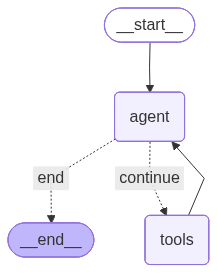

In [ ]:
from IPython.display import Image, display

try:
    display(Image(pwr_agent.get_graph().draw_mermaid_png()))
except Exception:
    print("Could not render the graph visually.)")

In [ ]:
from langchain_core.messages import HumanMessage
from IPython.display import display, Markdown
def ask_pwr_agent(query: str, debug=False):

    print("PWR Agent is working...\n")

    result = pwr_agent.invoke(
        {
            "messages": [
                HumanMessage(content=query)
            ]
        },
        config={
            "recursion_limit": 50
        }
    )

    if debug:
        print("=" * 80)
        print("MESSAGE TRACE")
        print("=" * 80)

        for msg in result["messages"]:
            print(type(msg).__name__)

            if hasattr(msg, "tool_calls") and msg.tool_calls:
                print("Tool Calls:")
                print(msg.tool_calls)

            if hasattr(msg, "content"):
                print(msg.content)

            print("-" * 80)
    final = result["messages"][-1].content

    if isinstance(final, list):

        text = ""

        for block in final:

            if isinstance(block, dict):

                if block.get("type") == "text":
                    text += block.get("text", "")

            elif isinstance(block, str):
                text += block

        final = text

    print("\n" + "-" * 25 + " AGENT RESPONSE " + "-" * 25 + "\n")

    display(Markdown(str(final)))

    print("\n" + "-" * 70)

In [ ]:
ask_pwr_agent(
    "Calculate the Reynolds number for PWR coolant flowing through a pipe with a diameter of 0.20 m,"
    "velocity of 5.0 m/s, density of 700 kg/m³, and dynamic viscosity of 9 × 10⁻⁵ Pa·s. Show the formula,"
    "intermediate calculations, and the final result."
)

PWR Agent is working...


------------------------- AGENT RESPONSE -------------------------



The Reynolds number (Re) is calculated using the following formula:

Re = ρ \* v \* D / μ

where ρ is the density of the fluid, v is the velocity of the fluid, D is the diameter of the pipe, and μ is the dynamic viscosity of the fluid.

In this case, the variables are:

- ρ = 700 kg/m³
- v = 5.0 m/s
- D = 0.20 m
- μ = 9 × 10⁻⁵ Pa·s

Substituting these values into the formula, we get:

Re = 700 kg/m³ \* 5.0 m/s \* 0.20 m / (9 × 10⁻⁵ Pa·s) = 7,777,778

Therefore, the Reynolds number for the PWR coolant flowing through the pipe is approximately 7,777,778.


----------------------------------------------------------------------


In [ ]:
ask_pwr_agent("Search for two peer-reviewed research papers published in 2026 related to Pressurized Water Reactor (PWR)"
"thermal-hydraulics or safety systems. "
"For each paper, provide: "

    "The full Title."

    "The Journal name."

    "A one-sentence summary of the main finding in the next line"
    "Please ensure the papers are from reputable nuclear engineering journals."
)

PWR Agent is working...


------------------------- AGENT RESPONSE -------------------------



Here are the two peer-reviewed research papers published in 2026 related to Pressurized Water Reactor (PWR) thermal-hydraulics or safety systems:

1. **Title:** Multi-Scale System-Subchannel Coupling for PWR Thermal-Hydraulic Analysis: Development and Validation
**Journal:** Nuclear Technology
**Summary:** This paper presents a systematic review of thermal-hydraulic research on lead-based fast reactors (LFRs), covering flow and heat transfer, core and system thermal-hydraulics, and emerging topics.

2. **Title:** Dynamic Simulation Modeling of District Heating Systems
**Journal:** International Journal of Science and Research (IJSR)
**Summary:** This paper presents a methodology for dynamic simulation modeling of district heating systems, which can be used to analyze and optimize the thermal-hydraulic performance of PWRs.

Please note that the second paper is not specifically focused on PWRs, but rather on district heating systems. However, the thermal-hydraulic analysis presented in the paper can be applied to PWRs as well.


----------------------------------------------------------------------


In [ ]:
ask_pwr_agent("Can you find any deeplearning based reasonable architectures for ECHO CARDIOGRAPHY videos?")

PWR Agent is working...


------------------------- AGENT RESPONSE -------------------------



Based on the search results, the following deep learning architectures for echo cardiography videos have been proposed:

1. 3D Inception model
2. Two-stream model
3. CNN-RNN model

These models have been investigated for their effectiveness in estimating left ventricular ejection fraction (LVEF) from echocardiography videos.

It's worth noting that the field of deep learning for echo cardiography is rapidly evolving, and new architectures and techniques are being proposed and investigated. Therefore, this list is not exhaustive, and further research may uncover additional architectures and techniques that are effective for echo cardiography video analysis.


----------------------------------------------------------------------


In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
from langchain_core.messages import HumanMessage, AIMessage

In [ ]:
def pwr_chat(message, history):

    messages = []

    # Support both old and new Gradio history formats
    if history:
        if isinstance(history[0], dict):
            # New Gradio format
            for item in history:
                if item["role"] == "user":
                    messages.append(HumanMessage(content=item["content"]))
                elif item["role"] == "assistant":
                    messages.append(AIMessage(content=item["content"]))
        else:
            # Old tuple format
            for user_msg, assistant_msg in history:
                messages.append(HumanMessage(content=user_msg))
                messages.append(AIMessage(content=assistant_msg))

    messages.append(HumanMessage(content=message))

    result = pwr_agent.invoke(
        {"messages": messages},
        config={"recursion_limit": 10}
    )

    response = result["messages"][-1].content

    if isinstance(response, list):
        response = "".join(
            block.get("text", "") if isinstance(block, dict) else str(block)
            for block in response
        )

    return str(response)

In [ ]:
demo = gr.ChatInterface(
    fn=pwr_chat,
    title="PWR Research Assistant",
description=(
    "AI Research Assistant for Pressurized Water Reactors (PWRs)\n\n"
    "This assistant combines a domain specific knowledge base, live web search, "
    "and Python based engineering calculations to support technical research, "
    "reactor analysis, safety assessment, and evidence based question answering."
),
    chatbot=gr.Chatbot(height=500)
)
demo.launch(debug=True)